##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
# If a package is missing, run this once:
# !pip -q install transformers scikit-learn requests pillow matplotlib pandas

import os
from pathlib import Path
from io import BytesIO
from collections import Counter

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

MODEL_ID = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Loaded {MODEL_ID}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded facebook/dinov2-small


Loaded 20 images
Labels count: Counter({'cat': 10, 'dog': 10})


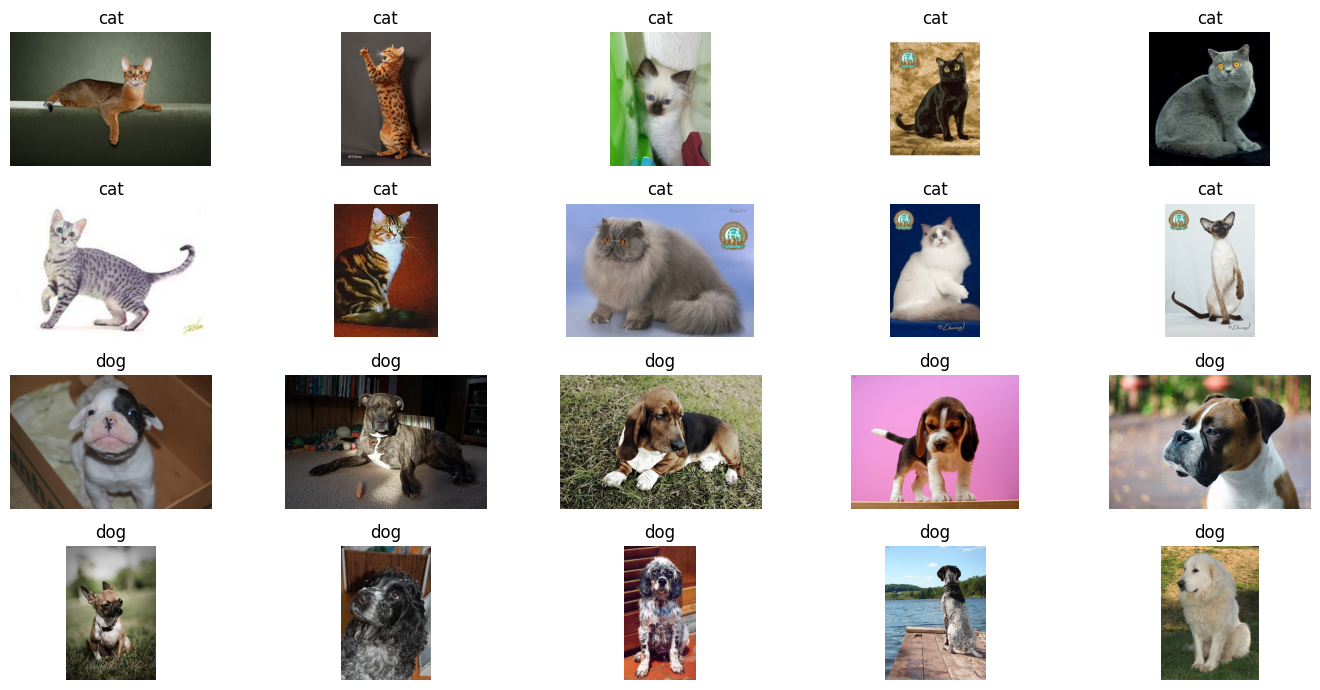

In [4]:
base_url = "https://raw.githubusercontent.com/ml4py/dataset-iiit-pet/master/images/"

cat_breeds = [
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay",
    "British_Shorthair",
    "Egyptian_Mau",
    "Maine_Coon",
    "Persian",
    "Ragdoll",
    "Siamese",
]

dog_breeds = [
    "american_bulldog",
    "american_pit_bull_terrier",
    "basset_hound",
    "beagle",
    "boxer",
    "chihuahua",
    "english_cocker_spaniel",
    "english_setter",
    "german_shorthaired",
    "great_pyrenees",
]

data_dir = Path("data/oxford_pet_20")
data_dir.mkdir(parents=True, exist_ok=True)

image_paths = []
true_labels = []

def download_one_image(breed, label):
    """
    Try image number 1,2,3,... until one works.
    This prevents 404 errors if a specific file number is missing.
    """
    for idx in range(1, 20):
        filename = f"{breed}_{idx}.jpg"
        url = base_url + filename
        path = data_dir / filename

        try:
            if not path.exists():
                response = requests.get(url, timeout=30)

                if response.status_code != 200:
                    continue

                path.write_bytes(response.content)

            # Check that the image opens correctly
            Image.open(path).convert("RGB")

            return path

        except Exception:
            if path.exists():
                path.unlink()
            continue

    raise FileNotFoundError(f"Could not download image for breed: {breed}")


# Download 10 cats
for breed in cat_breeds:
    path = download_one_image(breed, "cat")
    image_paths.append(path)
    true_labels.append("cat")

# Download 10 dogs
for breed in dog_breeds:
    path = download_one_image(breed, "dog")
    image_paths.append(path)
    true_labels.append("dog")

print(f"Loaded {len(image_paths)} images")
print("Labels count:", Counter(true_labels))

plt.figure(figsize=(14, 7))

for i, (path, label) in enumerate(zip(image_paths, true_labels)):
    img = Image.open(path).convert("RGB")
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
@torch.no_grad()
def get_global_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    outputs = model(**inputs)

    # CLS token = first token, represents the whole image
    cls_token = outputs.last_hidden_state[:, 0, :]

    # Normalize the vector
    cls_token = F.normalize(cls_token, p=2, dim=1)

    return cls_token.squeeze(0).cpu().numpy()


embeddings = np.vstack([get_global_embedding(path) for path in image_paths])

print("Embedding matrix shape:", embeddings.shape)
print("This means: 20 images × 384 features")

Embedding matrix shape: (20, 384)
This means: 20 images × 384 features


In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# K-Means cluster numbers are random, so map each cluster to cat/dog using majority vote
cluster_to_label = {}

for cluster_id in sorted(set(clusters)):
    labels_inside_cluster = [
        true_labels[i] for i in range(len(true_labels)) if clusters[i] == cluster_id
    ]

    majority_label = Counter(labels_inside_cluster).most_common(1)[0][0]
    cluster_to_label[cluster_id] = majority_label

predicted_labels = [cluster_to_label[c] for c in clusters]

accuracy = accuracy_score(true_labels, predicted_labels)

print("Cluster mapping:", cluster_to_label)
print(f"Clustering accuracy: {accuracy * 100:.2f}%")

results = pd.DataFrame({
    "image": [p.name for p in image_paths],
    "true_label": true_labels,
    "cluster": clusters,
    "predicted_label": predicted_labels,
    "correct": [t == p for t, p in zip(true_labels, predicted_labels)]
})

display(results)

print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels, labels=["cat", "dog"]))

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Cluster mapping: {np.int32(0): 'cat', np.int32(1): 'dog'}
Clustering accuracy: 95.00%


,image,true_label,cluster,predicted_label,correct
0,Abyssinian_1.jpg,cat,0,cat,True
1,Bengal_1.jpg,cat,0,cat,True
2,Birman_1.jpg,cat,0,cat,True
3,Bombay_1.jpg,cat,0,cat,True
4,British_Shorthair_2.jpg,cat,0,cat,True
5,Egyptian_Mau_1.jpg,cat,0,cat,True
6,Maine_Coon_1.jpg,cat,0,cat,True
7,Persian_1.jpg,cat,0,cat,True
8,Ragdoll_1.jpg,cat,0,cat,True
9,Siamese_5.jpg,cat,0,cat,True


Confusion Matrix:
[[10  0]
 [ 1  9]]

Classification Report:
              precision    recall  f1-score   support

         cat       0.91      1.00      0.95        10
         dog       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



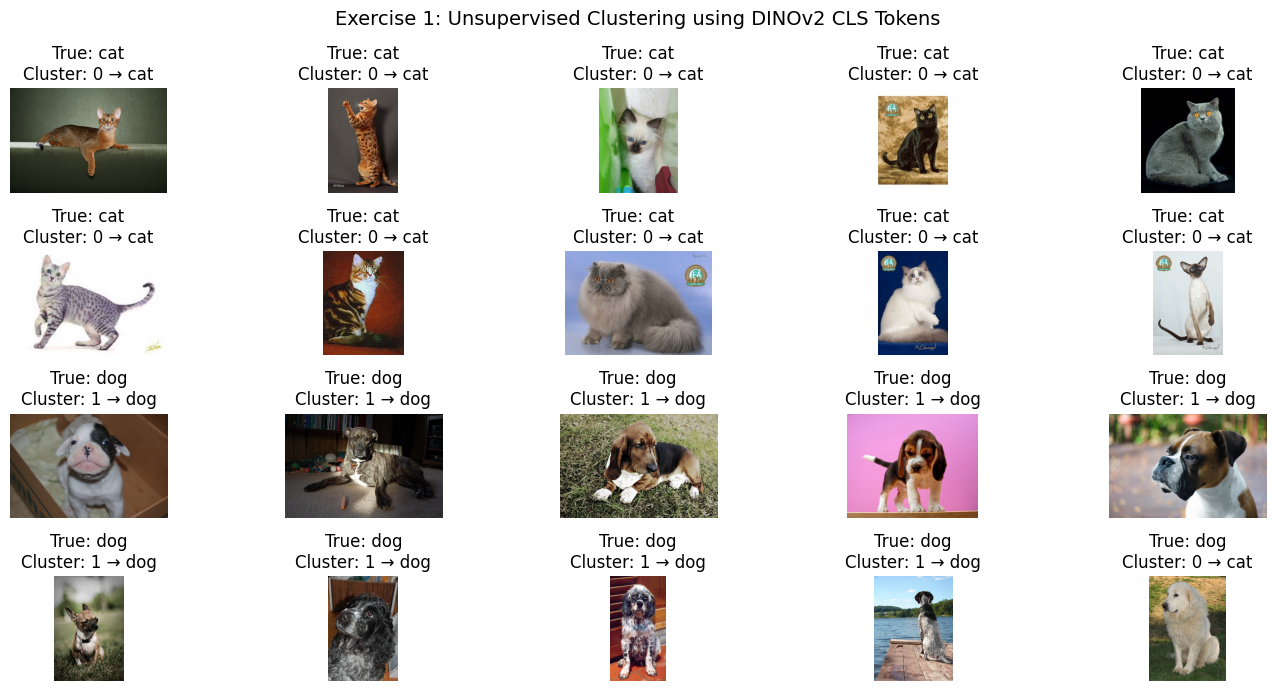

In [7]:
plt.figure(figsize=(14, 7))

for i, (path, true_label, pred_label, cluster) in enumerate(
    zip(image_paths, true_labels, predicted_labels, clusters)
):
    img = Image.open(path).convert("RGB")

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nCluster: {cluster} → {pred_label}")
    plt.axis("off")

plt.suptitle("Exercise 1: Unsupervised Clustering using DINOv2 CLS Tokens", fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).


In [15]:
CLASSIFIER_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

classifier_processor = AutoImageProcessor.from_pretrained(CLASSIFIER_MODEL_ID)
classifier_model = AutoModelForImageClassification.from_pretrained(CLASSIFIER_MODEL_ID).to(device)
classifier_model.eval()

print(f"Loaded {CLASSIFIER_MODEL_ID}")

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Loaded facebook/dinov2-small-imagenet1k-1-layer


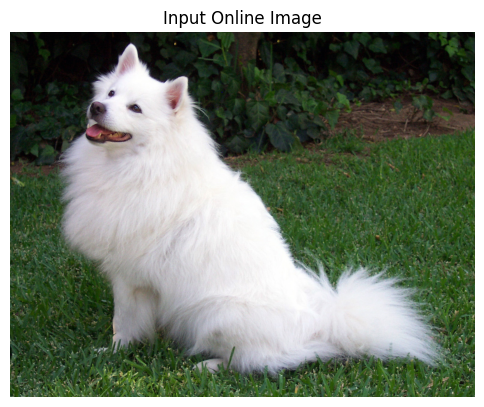

Top 5 ImageNet predictions:
1. Samoyed, Samoyede: 67.40%
2. Pomeranian: 25.70%
3. keeshond: 2.47%
4. Great Pyrenees: 1.36%
5. Japanese spaniel: 0.93%


In [14]:
# Exercise 2: Classify an online image using DINOv2 classifier
# This uses a stable online dog image from PyTorch Hub.

from io import BytesIO
import requests
from PIL import Image
import matplotlib.pyplot as plt
import torch

image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(image_url, headers=headers, timeout=30)
response.raise_for_status()

img = Image.open(BytesIO(response.content)).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Input Online Image")
plt.axis("off")
plt.show()

inputs = classifier_processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classifier_model(**inputs)
    probabilities = torch.softmax(outputs.logits, dim=-1)[0]

top5 = torch.topk(probabilities, k=5)

print("Top 5 ImageNet predictions:")

for rank, (score, class_id) in enumerate(zip(top5.values, top5.indices), start=1):
    label = classifier_model.config.id2label[class_id.item()]
    print(f"{rank}. {label}: {score.item() * 100:.2f}%")

### Observation

In Exercise 2, I used the DINOv2 model with a pre-trained ImageNet-1k classification head: `facebook/dinov2-small-imagenet1k-1-layer`.

The model successfully processed an online image and returned the top 5 predicted ImageNet categories with confidence scores. Since the input image contains a dog, the model predictions are expected to include dog-related ImageNet classes. This shows how DINOv2 visual features can be mapped to specific classification labels using the trained linear head.

